# *Koduppgifter - Kapitel 6*

### **Koduppgift 7 - K-means på housing.csv**

**7a) Förklara vad koden gör**

Koden läser först in olika bibliotek som behövs för att arbeta med data, skapa K-means-modellen och visualisera resultatet. Därefter läses datasetet housing.csv in som en Pandas DataFrame. Från datasetet väljs tre variabler ut: median_income, latitude och longitude. Dessa variabler används sedan som underlag för klustringen.

KMeans(n_clusters=6) innebär att vi ber K-means-algoritmen att dela in observationerna i sex olika kluster. fit_predict() gör två saker: modellen tränas på datan och varje observation får samtidigt ett klusternummer. Klustren får numren 0–5.

Till sist används Seaborn för att göra ett diagram där longitude ligger på x-axeln och latitude på y-axeln. Färgen visar vilket kluster varje observation tillhör. På så sätt kan man se hur de olika klustren är geografiskt fördelade.

Det här är ett exempel på unsupervised learning, eftersom datan inte har någon given label som modellen ska försöka förutsäga. Istället försöker modellen hitta grupper eller strukturer i datan själv. I ett affärssammanhang kan detta exempelvis användas för segmentering.

In [31]:
# 7a) importera bibliotek
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
import matplotlib.image as mpimg

In [32]:
# 7a) Läser in housing-datasetet
df = pd.read_csv("dataset/housing.csv")

In [ ]:
# 7a) Väljer de tre variabler som ska användas vid klustringen
X = df.loc[:, ["median_income", "latitude", "longitude"]]

In [34]:
# 7a) Visar de fem första raderna
print(X.head())

   median_income  latitude  longitude
0         8.3252     37.88    -122.23
1         8.3014     37.86    -122.22
2         7.2574     37.85    -122.24
3         5.6431     37.85    -122.25
4         3.8462     37.85    -122.25


In [35]:
# 7a) Skapar en K-means-modell med sex kluster
kmeans = KMeans(n_clusters=6)

In [36]:
# 7a) Tränar modellen och tilldelar varje observation ett kluster
X["Cluster"] = kmeans.fit_predict(X)

In [37]:
# 7a) Gör klustret till en kategorisk variabel
X["Cluster"] = X["Cluster"].astype("category")

In [38]:
# 7a) Visar de fem första raderna igen, nu även med klustertillhörighet
print(X.head())

   median_income  latitude  longitude Cluster
0         8.3252     37.88    -122.23       2
1         8.3014     37.86    -122.22       2
2         7.2574     37.85    -122.24       2
3         5.6431     37.85    -122.25       2
4         3.8462     37.85    -122.25       0


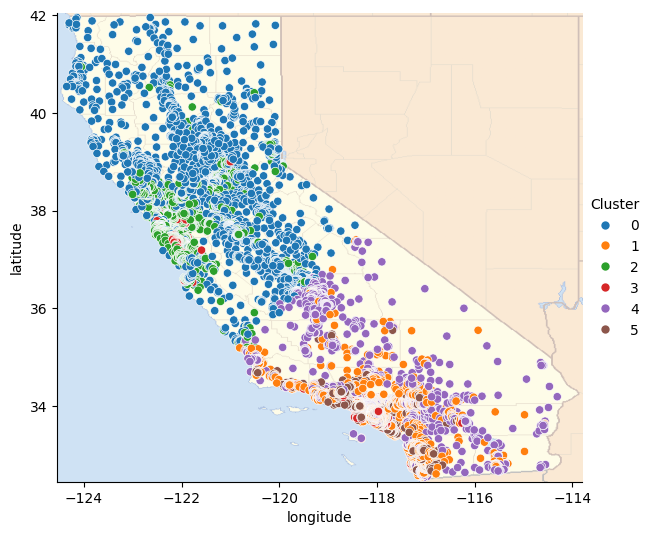

In [ ]:
# 7a) Visualiserar klustren geografiskt. Observationerna färgas efter vilket kluster de tillhör

california_img = mpimg.imread("dataset/california.png")

sns.relplot(
    x="longitude",
    y="latitude",
    hue="Cluster",
    data=X,
    height=6,
)

plt.imshow(
    california_img,
    extent=[-124.55, -113.80, 32.45, 42.05],
    alpha=0.5,
    cmap=plt.get_cmap("jet"),
)

plt.show()

**7b) Vilken information hade du velat ha om respektive kluster och hur hade du designat marknadsundersökningen?**

Om jag hade lett undersökningen hade jag först velat förstå vad som kännetecknar personerna eller hushållen i varje kluster. Bara information om exempelvis geografiskt område och medianinkomst räcker inte för att förstå vilka preferenser gruppen faktiskt har.

Jag hade därför velat samla in information om exempelvis ålder, hushållsstorlek, antal barn, boendeform, bostadens storlek, antal rum, inkomstnivå och ungefärligt bostadspris. Jag hade också velat veta vilka typer av bostäder personerna föredrar, till exempel villa, lägenhet eller radhus.

Eftersom uppgiften specifikt nämner marknadsföring hade jag även frågat hur personerna helst vill bli kontaktade, exempelvis via e-post, telefon, sociala medier eller fysisk reklam. Jag hade också undersökt vilka typer av produkter eller bostäder de är intresserade av och vad som är viktigt när de väljer bostad.

Jag hade genomfört undersökningen genom ett enkätformulär, eftersom det gör det möjligt att samla in samma typ av information från många personer. Jag hade försökt få svar från personer från de olika klustren så att varje kluster blir representerat.

Sedan hade jag jämfört svaren mellan klustren. Exempelvis kanske ett kluster framför allt består av personer som föredrar större hus och vill bli kontaktade via e-post, medan ett annat kluster kanske främst består av personer som föredrar mindre bostäder och sociala medier.

Det är viktigt att inte automatiskt anta att alla personer i ett kluster har exakt samma preferenser. Ett kluster är en grupp som modellen har skapat utifrån de variabler som användes i analysen. Därför behöver man undersöka gruppen närmare för att förstå varför observationerna hamnade tillsammans.

**7c) Hur kan resultatet vara användbart i verkligheten för ett företag?**

Resultatet kan användas för att segmentera kunder eller områden. Istället för att behandla alla kunder som en enda stor grupp kan företaget upptäcka att det finns olika grupper med olika egenskaper.

Om ett företag exempelvis arbetar med bostäder skulle klustringen kunna hjälpa företaget att förstå vilka områden eller grupper som liknar varandra utifrån exempelvis inkomst och geografisk position.

Företaget skulle sedan kunna anpassa sin marknadsföring efter de olika segmenten. Ett segment kanske är mer intresserat av dyrare och större bostäder medan ett annat segment kanske är mer intresserat av billigare bostäder. Företaget kan då anpassa vilka bostäder som marknadsförs till olika grupper och hur kommunikationen utformas.

Detta passar också med hur klustring beskrivs i kursmaterialet. Inom affärssammanhang kan klustring användas för segmentering, där olika segment exempelvis kan kommuniceras med på olika sätt eller erbjudas olika produkter.

En annan fördel är att företaget kan få en bättre förståelse för sin kundbas. Istället för att bara titta på genomsnittet kan man upptäcka att det finns flera olika grupper med olika behov.

Samtidigt måste företaget vara försiktigt med hur resultatet tolkas. Klustren skapas utifrån de variabler som modellen får använda. Om man använder dålig eller otillräcklig data kan resultatet också bli missvisande. Kursmaterialet lyfter just att datakvalitet och feature selection är viktiga delar i praktiska ML-projekt.

**7d) Utveckla kodexemplet – undersök hur många kluster som är lämpliga**

Jag utvecklade koden genom att testa olika antal kluster istället för att bara använda sex kluster. Jag testade mellan 2 och 10 kluster och använde både inertia och silhouette score för att jämföra modellerna.
Inertia visar hur nära observationerna ligger sina klustercentrum. När antalet kluster ökar minskar inertia, men efter ett tag blir förbättringen mindre. Därför kan man titta efter en så kallad ”elbow” i grafen för att få en uppfattning om vilket antal kluster som kan vara rimligt.
Silhouette score ger ytterligare information om hur väl observationerna passar in i sina kluster. Ett högre värde innebär generellt att observationerna passar bättre i sina kluster.
Genom att använda båda måtten får man ett bättre underlag för att bedöma vilket antal kluster som kan vara lämpligt.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [41]:
df = pd.read_csv("dataset/housing.csv")

X = df.loc[:, ["median_income", "latitude", "longitude"]]
X.head()

,median_income,latitude,longitude
0,8.3252,37.88,-122.23
1,8.3014,37.86,-122.22
2,7.2574,37.85,-122.24
3,5.6431,37.85,-122.25
4,3.8462,37.85,-122.25


In [42]:
inertias = []

for k in range(2, 11):

    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

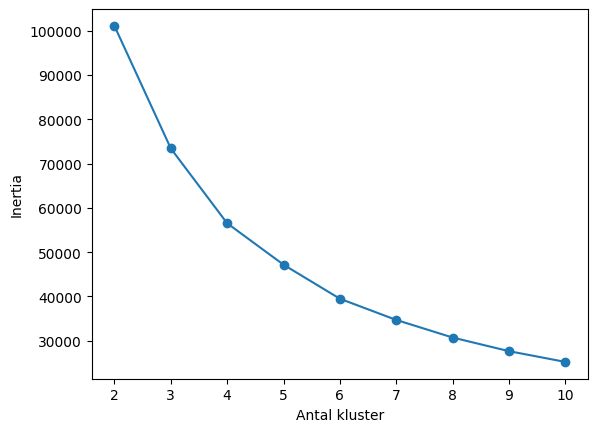

In [43]:
plt.plot(range(2, 11), inertias, marker="o")

plt.xlabel("Antal kluster")
plt.ylabel("Inertia")

plt.show()

In [44]:
for k in range(2, 11):

    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    print(f"Antal kluster: {k}, Silhouette score: {score:.3f}")

Antal kluster: 2, Silhouette score: 0.567
Antal kluster: 3, Silhouette score: 0.503
Antal kluster: 4, Silhouette score: 0.425
Antal kluster: 5, Silhouette score: 0.375
Antal kluster: 6, Silhouette score: 0.399
Antal kluster: 7, Silhouette score: 0.364
Antal kluster: 8, Silhouette score: 0.344
Antal kluster: 9, Silhouette score: 0.348
Antal kluster: 10, Silhouette score: 0.354


### **Slutsats**
När jag testar olika antal kluster ser jag att inertia minskar när antalet kluster ökar. Kurvan börjar plana ut ungefär efter 5–6 kluster. Silhouette score är däremot högst vid 2 kluster med 0,567 och minskar när fler kluster används. Resultaten visar därför att valet av antal kluster kan bero på vilket mått och vilket användningsområde man utgår från. 

### **Koduppgift 9 - 1980sClassics.csv**

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

### **Load Data**

In [46]:
df = pd.read_csv("dataset/1980sClassics.csv")

df.head()

,Track,Artist,Duration,Time_Signature,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Popularity,Year
0,Babe,Styx,3:38,4,0.700,0.582,11,-5.960,0,0.0356,0.05020,0.000000,0.0881,0.785,116.712,96,1980
1,The Rose,Bette Midler,4:04,4,0.264,0.640,8,-6.221,1,0.0442,0.03930,0.000002,0.1510,0.190,84.828,92,1980
2,Cars,Gary Numan,4:08,4,0.338,0.562,9,-7.181,1,0.0290,0.03900,0.000000,0.1070,0.259,149.907,82,1980
3,Magic,Olivia Newton-John,2:17,4,0.911,0.689,1,-6.176,1,0.2650,0.00119,0.000000,0.0704,0.546,140.034,80,1980
4,We Don’t Talk Anymore,Cliff Richard,3:37,4,0.728,0.563,1,-8.053,0,0.1340,0.62100,0.000000,0.1790,0.352,100.017,80,1980


### **Data Exploration**

In [47]:
df.shape

(998, 17)

In [48]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 998 entries, 0 to 997
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Track             998 non-null    str    
 1   Artist            998 non-null    str    
 2   Duration          998 non-null    str    
 3   Time_Signature    998 non-null    int64  
 4   Danceability      998 non-null    float64
 5   Energy            998 non-null    float64
 6   Key               998 non-null    int64  
 7   Loudness          998 non-null    float64
 8   Mode              998 non-null    int64  
 9   Speechiness       998 non-null    float64
 10  Acousticness      998 non-null    float64
 11  Instrumentalness  998 non-null    float64
 12  Liveness          998 non-null    float64
 13  Valence           998 non-null    float64
 14  Tempo             998 non-null    float64
 15  Popularity        998 non-null    int64  
 16  Year              998 non-null    int64  
dtypes: float

In [49]:
df.isna().sum()

Track               0
Artist              0
Duration            0
Time_Signature      0
Danceability        0
Energy              0
Key                 0
Loudness            0
Mode                0
Speechiness         0
Acousticness        0
Instrumentalness    0
Liveness            0
Valence             0
Tempo               0
Popularity          0
Year                0
dtype: int64

In [50]:
df.duplicated().sum()

np.int64(1)

### **Data Preparation**

In [51]:
df = df.drop_duplicates().copy()

df.shape

(997, 17)

### **Feature selection**

Jag väljer att använda musikaliska egenskaper som beskriver låtarnas ljud och stil:

- Danceability
- Energy
- Loudness
- Speechiness
- Acousticness
- Instrumentalness
- Liveness
- Valence
- Tempo

Jag använder inte Track och Artist eftersom de är textvariabler. Duration är också textformaterad. Jag väljer även att inte använda Year och Popularity eftersom jag främst vill gruppera låtar utifrån deras musikaliska egenskaper och inte utifrån när låten släpptes eller hur populär den är.

Key, Mode och Time_Signature är diskreta variabler och jag väljer därför att inte använda dem i denna K-means-analys.

In [53]:
features = [
    "Danceability",
    "Energy",
    "Loudness",
    "Speechiness",
    "Acousticness",
    "Instrumentalness",
    "Liveness",
    "Valence",
    "Tempo",
]

X = df[features]
X.head()

,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo
0,0.700,0.582,-5.960,0.0356,0.05020,0.000000,0.0881,0.785,116.712
1,0.264,0.640,-6.221,0.0442,0.03930,0.000002,0.1510,0.190,84.828
2,0.338,0.562,-7.181,0.0290,0.03900,0.000000,0.1070,0.259,149.907
3,0.911,0.689,-6.176,0.2650,0.00119,0.000000,0.0704,0.546,140.034
4,0.728,0.563,-8.053,0.1340,0.62100,0.000000,0.1790,0.352,100.017


In [54]:
X.describe()

,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo
count,997.000000,997.000000,997.000000,997.000000,997.000000,997.000000,997.000000,997.000000,997.000000
mean,0.626461,0.633470,-8.884724,0.057635,0.244258,0.042586,0.178669,0.602973,120.938401
std,0.151593,0.203861,3.831563,0.055768,0.248486,0.157133,0.162722,0.257973,26.245862
min,0.174000,0.018300,-28.980000,0.022700,0.000003,0.000000,0.022300,0.028700,61.530000
25%,0.534000,0.489000,-11.262000,0.031700,0.043300,0.000000,0.083900,0.388000,102.477000
50%,0.633000,0.652000,-8.269000,0.039300,0.155000,0.000022,0.113000,0.644000,119.972000
75%,0.735000,0.797000,-6.042000,0.056500,0.385000,0.001380,0.226000,0.825000,135.003000
max,0.988000,0.994000,-1.496000,0.524000,0.996000,0.974000,0.981000,0.984000,208.571000


### **Feature Scaling**

In [55]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### **Choosing the Number of Clusters**

K-means kräver att vi bestämmer hur många kluster vi vill använda. Därför testar jag flera olika värden på k.
Jag använder både inertia och silhouette score. Inertia används för att hitta en möjlig "elbow" där förbättringen börjar avta, medan silhouette score ger ytterligare information om hur väl observationerna passar in i sina kluster.

In [56]:
inertias = []
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

    labels = kmeans.fit_predict(X_scaled)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

In [57]:
results = pd.DataFrame(
    {
        "Antal kluster": range(2, 11),
        "Inertia": inertias,
        "Silhouette score": silhouette_scores,
    }
)

results

,Antal kluster,Inertia,Silhouette score
0,2,7235.352975,0.234616
1,3,6457.795346,0.168831
2,4,5750.758118,0.195578
3,5,5142.612232,0.189883
4,6,4727.646750,0.186338
5,7,4368.195016,0.171415
6,8,4074.233562,0.174070
7,9,3875.481601,0.178117
8,10,3719.111412,0.167949


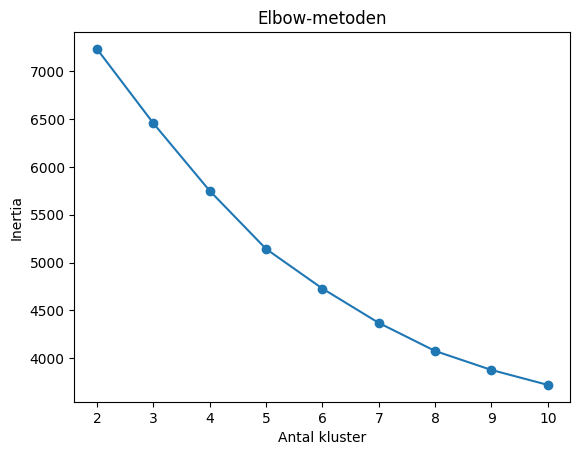

In [58]:
plt.plot(range(2, 11), inertias, marker="o")

plt.xlabel("Antal kluster")
plt.ylabel("Inertia")
plt.title("Elbow-metoden")

plt.show()

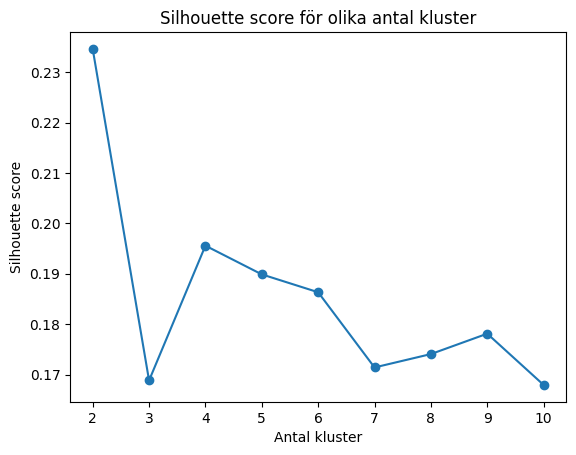

In [59]:
plt.plot(range(2, 11), silhouette_scores, marker="o")

plt.xlabel("Antal kluster")
plt.ylabel("Silhouette score")
plt.title("Silhouette score för olika antal kluster")

plt.show()

### **Choosing the Final Number of Clusters**

Silhouette score är högst vid två kluster med ett värde på ungefär 0,235. Inertia minskar däremot när antalet kluster ökar, men minskningen blir successivt mindre. Jag väljer därför två kluster i den slutliga modellen eftersom silhouette score ger tydligast stöd för detta val.

Resultatet visar samtidigt att klustren inte är väldigt tydligt separerade. Därför ska klustren tolkas som grupper av låtar med liknande musikaliska egenskaper och inte som helt tydliga musikgenrer.

### **Final K-means Model**

In [ ]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)

df["Cluster"] = kmeans.fit_predict(X_scaled)
df.head()

,Track,Artist,Duration,Time_Signature,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Popularity,Year,Cluster
0,Babe,Styx,3:38,4,0.700,0.582,11,-5.960,0,0.0356,0.05020,0.000000,0.0881,0.785,116.712,96,1980,0
1,The Rose,Bette Midler,4:04,4,0.264,0.640,8,-6.221,1,0.0442,0.03930,0.000002,0.1510,0.190,84.828,92,1980,1
2,Cars,Gary Numan,4:08,4,0.338,0.562,9,-7.181,1,0.0290,0.03900,0.000000,0.1070,0.259,149.907,82,1980,1
3,Magic,Olivia Newton-John,2:17,4,0.911,0.689,1,-6.176,1,0.2650,0.00119,0.000000,0.0704,0.546,140.034,80,1980,0
4,We Don’t Talk Anymore,Cliff Richard,3:37,4,0.728,0.563,1,-8.053,0,0.1340,0.62100,0.000000,0.1790,0.352,100.017,80,1980,1


### **Cluster Analysis**

In [61]:
df["Cluster"].value_counts().sort_index()

Cluster
0    696
1    301
Name: count, dtype: int64

In [ ]:
cluster_means = df.groupby("Cluster")[features].mean()
cluster_means.round(3)

,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo
Cluster,,,,,,,,,
0,0.668,0.728,-7.727,0.064,0.137,0.030,0.187,0.706,121.996
1,0.532,0.415,-11.561,0.042,0.493,0.072,0.159,0.364,118.493


### **Visualization**

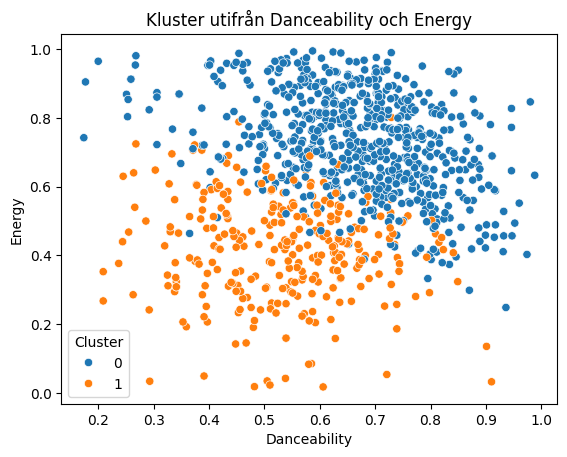

In [ ]:
sns.scatterplot(data=df, x="Danceability", y="Energy", hue="Cluster")
plt.title("Kluster utifrån Danceability och Energy")
plt.show()

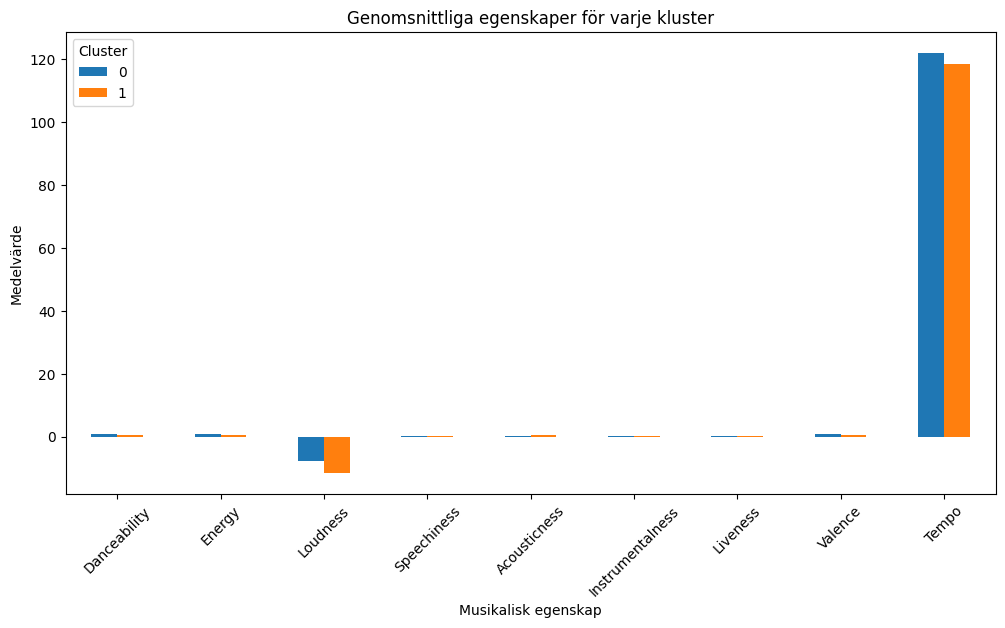

In [64]:
cluster_means.T.plot(kind="bar", figsize=(12, 6))

plt.xlabel("Musikalisk egenskap")
plt.ylabel("Medelvärde")
plt.title("Genomsnittliga egenskaper för varje kluster")
plt.xticks(rotation=45)

plt.show()

### **Interpretation**

Kluster 0 består av fler låtar och har i genomsnitt högre danceability och energy. Låtarna har också högre valence och är mindre akustiska. De har dessutom högre loudness och något högre tempo.

Kluster 1 har lägre danceability och energy och högre acousticness. Klustret har också lägre valence och lägre loudness.

Klustren verkar därför framför allt skilja sig åt när det gäller hur energiska, dansvänliga, positiva och akustiska låtarna är.

### **Conclusion**

Klustringsanalysen grupperade låtarna utifrån deras musikaliska egenskaper. Jag använde Danceability, Energy, Loudness, Speechiness, Acousticness, Instrumentalness, Liveness, Valence och Tempo som variabler och standardiserade dem innan K-means användes.

Jag testade mellan två och tio kluster. Silhouette score var högst vid två kluster, medan inertia minskade när antalet kluster ökade. Jag valde därför två kluster i den slutliga modellen, eftersom det gav det högsta silhouette score av de testade värdena på k.

Resultatet visar att den ena gruppen framför allt består av låtar med högre energy, danceability och valence, medan den andra gruppen i genomsnitt har lägre värden på dessa variabler och högre acousticness.

En sådan klustring skulle exempelvis kunna användas för att gruppera låtar med liknande musikaliska egenskaper och sedan använda grupperna för att skapa spellistor eller undersöka vilka typer av låtar som liknar varandra. Eftersom silhouette score inte är särskilt hög bör man dock inte tolka grupperna som helt tydliga eller fasta musikgenrer.